# Swin Transformer 阶段一：在 M1 上建立可信 baseline

**一句话心智模型：把同一张图片变成同一份 tensor，分别交给不同执行后端，先证明答案能对齐，再比较完成一次请求用了多久。**

本 Notebook 是可执行教程兼实验记录。依据 [`docs/swin-transformer-guideline.md`](../../docs/swin-transformer-guideline.md) §二建立 baseline，并按本次需求提前加入 §三的 CoreML 转换与 §十一的 execution-unit experiment。**本轮不做 INT8/INT4 量化。** FP16 是浮点精度转换，单独标注；另保留 CoreML FP32 对照。

顺序：下载 → 首次预测 → 固定输入 → CPU FP32 reference → MPS GPU → correctness debug → TorchScript → CoreML FP32/FP16 → 四种允许设备配置 → 性能/精度汇总 → 术语索引。

**结果边界：** 默认公开演示图片没有分类真值，只用于 smoke test 和数值一致性；准确率显示 `NaN`，绝不拿 baseline 预测当真值。提供带标签 CSV 后，同一流程自动输出 Top-1/Top-5。少量样本不支持“ImageNet 准确率下降不超过 0.5 pp”的结论。

**工程约束：** M1、batch=1、RGB、固定 `[1,3,224,224]`、同一 checkpoint、CPU FP32 为 reference。先记录而不承诺 FPS/SLO；还没做设备 trace 前，ANE 归属标为“未验证”。不预设 CoreML 或 GPU 一定更快。

## 0. 环境、执行方式与实验口径

从仓库根目录启动：

```bash
uv sync --locked
uv run python -m ipykernel install --user --name infer-proj --display-name "infer-proj (uv)"
uv run jupyter lab notebooks/swin_transformer/01_stage1_trustworthy_baseline.ipynb
```

`sync --locked` 按 `uv.lock` 安装，禁止悄悄改版本；`ipykernel install` 注册这份 uv 环境，编辑器中选择 **infer-proj (uv)**；`jupyter lab` 打开交互式教程。修改 MPS 环境变量后需要重启 kernel。不要在 Notebook 里 `%pip install` 另造环境。

默认 warmup=5、每轮20次、3轮是**快速实验**。正式记录至少增加到 warmup=20、每轮100次、5轮，并重复独立进程实验。M1 Air 无风扇，温升会影响结果；记录电源/后台负载/thermal 状态，交错后端次序，不能只跑一次就做优化结论。

内存数字分开看：RSS 是进程驻留内存；MPS allocator 是 PyTorch 管理的 GPU 分配。两者不能代表 ANE 峰值，也不能在 UMA 上简单相加。本轮只提供进程 high-water mark 和 MPS 快照，真正单后端峰值需隔离进程与 Instruments。

In [ ]:
import os
# 必须在 import torch 前设置；禁用 MPS 不支持算子自动回 CPU，出现问题时保留错误。
assert os.environ.get("PYTORCH_ENABLE_MPS_FALLBACK", "0") != "1", "重启 kernel，先关闭 MPS fallback"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "0"
from pathlib import Path
from datetime import datetime
import copy, hashlib, json, platform, time, resource, gc, subprocess
import importlib.metadata as metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import torch
import coremltools as ct
from transformers import AutoImageProcessor, AutoModelForImageClassification
from huggingface_hub import snapshot_download, hf_hub_download
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
RUN = ROOT / "results/swin_stage1" / datetime.now().strftime("%Y%m%d-%H%M%S-%f")
RUN.mkdir(parents=True)
ART = RUN / "artifacts"
ART.mkdir()
MODEL_ID = "microsoft/swin-tiny-patch4-window7-224"
REVISION = "d00d478bfaf1f417d34a1186673ad4b4be264c51"
IMAGE_REVISION = "58d012a2ab1d495008fc00428debdffb3ceddb3d"
LABEL_CSV = None  # 可改成 ROOT / "datasets/imagenet_val.csv"；路径规则见下文
MAX_IMAGES = 32   # 有标签 CSV 时固定取前32条；正式实验修改并说明采样方法
WARMUP, REPEATS, ROUNDS = 5, 20, 3
CPU_THREADS = 4
CONTEXT = "快速 smoke 实验；请补记：电源模式、后台负载、室温、是否刚跑过重负载"
torch.set_num_threads(CPU_THREADS)
torch.manual_seed(0)
np.random.seed(0)
plt.rcParams.update({"figure.figsize": (9, 4), "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": .2})

def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

manifest = {"model_id": MODEL_ID, "revision": REVISION, "image_revision": IMAGE_REVISION,
            "platform": platform.platform(), "machine": platform.machine(),
            "versions": {n: metadata.version(n) for n in
                         ["torch", "transformers", "coremltools", "numpy", "Pillow", "huggingface-hub"]},
            "shape": [1, 3, 224, 224], "input_dtype": "float32", "cpu_threads": CPU_THREADS,
            "warmup": WARMUP, "repeats": REPEATS, "rounds": ROUNDS, "context": CONTEXT,
            "mps_fallback": os.environ["PYTORCH_ENABLE_MPS_FALLBACK"],
            "uv_lock_sha256": sha256(ROOT / "uv.lock"), "device_mapping": "unverified"}
manifest["hardware"] = subprocess.run(["sysctl", "-n", "machdep.cpu.brand_string", "hw.memsize"], capture_output=True, text=True).stdout.strip()
manifest["power_status"] = subprocess.run(["pmset", "-g", "batt"], capture_output=True, text=True).stdout.strip()
manifest["thermal_status"] = subprocess.run(["pmset", "-g", "therm"], capture_output=True, text=True).stdout.strip()
manifest["cache_state"] = "uncontrolled; prior runs may have warmed model/compiler caches"
print(json.dumps(manifest, ensure_ascii=False, indent=2))
print("MPS available:", torch.backends.mps.is_available(), "\n本次产物:", RUN)

{
  "model_id": "microsoft/swin-tiny-patch4-window7-224",
  "revision": "d00d478bfaf1f417d34a1186673ad4b4be264c51",
  "image_revision": "58d012a2ab1d495008fc00428debdffb3ceddb3d",
  "platform": "macOS-26.6.2-arm64-arm-64bit",
  "machine": "arm64",
  "versions": {
    "torch": "2.7.0",
    "transformers": "4.51.3",
    "coremltools": "9.0",
    "numpy": "1.26.4",
    "Pillow": "12.3.0",
    "huggingface-hub": "0.36.2"
  },
  "shape": [
    1,
    3,
    224,
    224
  ],
  "input_dtype": "float32",
  "cpu_threads": 4,
  "warmup": 5,
  "repeats": 20,
  "rounds": 3,
  "context": "快速 smoke 实验；请补记：电源模式、后台负载、室温、是否刚跑过重负载",
  "mps_fallback": "0",
  "uv_lock_sha256": "05a84f6cc17fa31660714ea038f826b2bbf9c044604318967b90863d611bd9f4",
  "device_mapping": "unverified",
  "hardware": "Apple M1\n17179869184",
  "power_status": "Now drawing from 'AC Power'\n -InternalBattery-0 (id=8912995)\t80%; AC attached; not charging present: true",
  "thermal_status": "Note: No thermal warning level has been re

## 1. Hugging Face 下载：先直接跑一遍

`from_pretrained` 读两类数据：`config.json` 决定 Python 模块结构，`model.safetensors` 提供参数 tensor；`preprocessor_config.json` 决定像素如何进入模型。**revision 是仓库 commit，不是随时间变化的 main。** 缓存命中时不会重复下载权重。

`eval()` 切到推理行为（例如关闭 dropout）；`inference_mode()` 关闭自动求导记录。这两步负责的事情不同，都需要做。`AutoModelForImageClassification` 输出对象中 `logits` 是每个类别的未归一化分数，形状 `[batch, classes]`。本模型输出 `[1,1000]`，argmax 的轴是类别轴。

In [9]:
snapshot = Path(snapshot_download(MODEL_ID, revision=REVISION,
    allow_patterns=["config.json", "preprocessor_config.json", "model.safetensors"]))
processor = AutoImageProcessor.from_pretrained(snapshot, use_fast=False)
t0 = time.perf_counter()
model = AutoModelForImageClassification.from_pretrained(snapshot).eval().float().cpu()
manifest["cpu_model_load_ms"] = (time.perf_counter() - t0) * 1000
manifest["model_files"] = {p.name: sha256(p) for p in snapshot.iterdir() if p.is_file()}
manifest["model_bytes"] = sum(p.stat().st_size for p in snapshot.iterdir() if p.is_file())
manifest["processor"] = processor.to_dict()
print(type(model).__name__, "parameters:", sum(p.numel() for p in model.parameters()))
print(processor)
print("前处理配置原文:", (snapshot / "preprocessor_config.json").read_text())

Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 1313.46it/s]

SwinForImageClassification parameters: 28288354
ViTImageProcessor {
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

前处理配置原文: {
  "do_normalize": true,
  "do_resize": true,
  "feature_extractor_type": "ViTFeatureExtractor",
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "size": 224
}


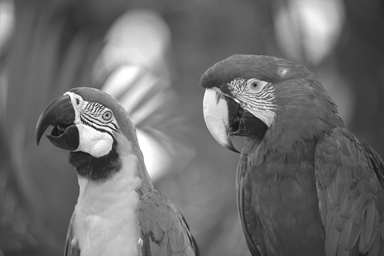

首次 CPU forward ms（不含下载/加载/前处理）: 76.38962497003376


,class_id,label,softmax_score
0,88,macaw,0.893125
1,23,vulture,0.001886
2,89,"sulphur-crested cockatoo, Kakatoe galerita, Ca...",0.001866
3,21,kite,0.001296
4,87,"African grey, African gray, Psittacus erithacus",0.001009


In [10]:
image_path = hf_hub_download("huggingface/documentation-images", "hub/parrots.png",
    repo_type="dataset", revision=IMAGE_REVISION)
with Image.open(image_path) as im:
    demo_image = ImageOps.exif_transpose(im).convert("RGB")
display(demo_image.resize((384, 256)))  # 仅显示缩略图，不作为模型输入
x_demo = processor(images=demo_image, return_tensors="pt")["pixel_values"]
t0 = time.perf_counter()
with torch.inference_mode():
    demo_logits = model(pixel_values=x_demo).logits
manifest["cpu_first_forward_ms"] = (time.perf_counter() - t0) * 1000
print("首次 CPU forward ms（不含下载/加载/前处理）:", manifest["cpu_first_forward_ms"])
scores, ids = demo_logits.softmax(-1).topk(5)
display(pd.DataFrame({"class_id": ids[0].tolist(),
    "label": [model.config.id2label[i] for i in ids[0].tolist()],
    "softmax_score": scores[0].tolist()}))

## 2. 固定数据和前处理契约

正常路径：磁盘图片 → 解码 → EXIF 方向校正 → RGB → processor resize/rescale/normalize → NCHW FP32 tensor。
这个 checkpoint 的配置来自旧 `ViTFeatureExtractor`；不要凭“Swin”名字擅自套用 torchvision 的短边 resize + center crop。上一个单元格打印的实际 processor 才是本轮契约。

例如红通道像素128：先 `128/255≈0.502`，再 `(0.502−0.485)/0.229≈0.074`。G/B 通道用各自 mean/std。这只是训练使用的固定仿射变换，不保证每张图的均值都为0、方差都为1。

正式准确率使用 UTF-8 CSV，三列 `path,label,label_name`。`path` 相对于 CSV 所在目录；`label` 必须是 **当前 checkpoint 的 0～999 类别编号**；`label_name` 必须与 `model.config.id2label[label]` 一致。不要直接拿 ImageFolder 自动生成的类别编号，也不要把 ILSVRC 原始 1-based ID 减1后未经映射验证就使用。先用数据集 synset/类别表对齐当前 config。

示例结构（内容需换成真实标注，不能填模型预测）：

```csv
path,label,label_name
images/example.JPEG,真实类别编号,"config中对应的完整类别名称"
```

默认只用公开鹦鹉图的原图、镜像、中心区域三种输入；它们相关且没有真值。它们能发现转换/前处理问题，不能构成有代表性的 validation dataset。

In [11]:
def read_rgb(path):
    with Image.open(path) as im:
        return ImageOps.exif_transpose(im).convert("RGB")

if LABEL_CSV is not None:
    label_path = Path(LABEL_CSV).resolve()
    records = pd.read_csv(label_path).head(MAX_IMAGES)
    assert len(records) > 0 and {"path", "label", "label_name"} <= set(records.columns)
    assert records["label"].between(0, 999).all()
    assert (records["label"] == records["label"].astype(int)).all()
    labels = records["label"].to_numpy(dtype=int)
    assert all(str(name) == model.config.id2label[int(i)]
               for i, name in zip(labels, records["label_name"]))
    paths = [(label_path.parent / p).resolve() for p in records["path"]]
    images = [read_rgb(p) for p in paths]
    sample_ids = records["path"].tolist()
    manifest["dataset"] = {"kind": "labelled CSV subset", "csv_sha256": sha256(label_path),
        "selection": f"first {MAX_IMAGES} CSV rows; no claim of representative sampling",
        "files": [{"id": s, "sha256": sha256(p), "label": int(y)}
                  for s, p, y in zip(sample_ids, paths, labels)]}
else:
    w, h = demo_image.size
    images = [demo_image, ImageOps.mirror(demo_image), demo_image.crop((w//4, h//4, 3*w//4, 3*h//4))]
    labels = None
    sample_ids = ["parrots/original", "parrots/mirror", "parrots/center-half"]
    manifest["dataset"] = {"kind": "unlabelled correlated smoke images", "source_sha256": sha256(image_path),
                           "transforms": sample_ids}

# batch 始终为1：每个数组是一次请求，不能把全部样本合成一个大 batch 测量。
inputs = [processor(images=im, return_tensors="pt")["pixel_values"].contiguous() for im in images]
assert all(x.shape == (1, 3, 224, 224) and x.dtype == torch.float32 for x in inputs)
np.savez(RUN / "inputs.npz", **{f"input_{i}": x.numpy() for i, x in enumerate(inputs)})
manifest["input_sha256"] = sha256(RUN / "inputs.npz")
manifest["n_images"] = len(inputs)
print("固定输入:", len(inputs), inputs[0].shape, "range:", (inputs[0].min().item(), inputs[0].max().item()))
print("有真实标签:", labels is not None)

固定输入: 3 torch.Size([1, 3, 224, 224]) range: (-1.7582842111587524, 2.640000104904175)
有真实标签: False


### 为什么 HWC/NCHW 不能只改 shape？先看真实数字

一个 RGB 的1×2图，两个像素分别 `[10,20,30]` 和 `[40,50,60]`，下面用 FP32 展示地址。
N=1 是 batch，C=3 是颜色/特征轴，H=1/W=2 是空间轴；这里没有 reduction 轴。HWC 是像素相邻通道连续；NCHW 是同一通道的空间元素连续。

| 元素偏移 | 字节地址（基址0） | 值 | 原 HWC 下标 |
|---:|---:|---:|---|
|0|0|10|[0,0,0] R0|
|1|4|20|[0,0,1] G0|
|2|8|30|[0,0,2] B0|
|3|12|40|[0,1,0] R1|
|4|16|50|[0,1,1] G1|
|5|20|60|[0,1,2] B1|

转成 CHW 时，输出位置依次要去原内存读取：

| CHW 坐标 | 原字节地址展开式 | 原物理偏移 | 读到的值 |
|---|---|---:|---:|
|[0,0,0]|4×(0×2×3+0×3+0)|0|10|
|[0,0,1]|4×(0×2×3+1×3+0)|3|40|
|[1,0,0]|4×(0×2×3+0×3+1)|1|20|
|[1,0,1]|4×(0×2×3+1×3+1)|4|50|
|[2,0,0]|4×(0×2×3+0×3+2)|2|30|
|[2,0,1]|4×(0×2×3+1×3+2)|5|60|

所以正确 CHW 连续内存是 `[10,40,20,50,30,60]`。直接 reshape 只会得到原顺序 `[10,20,30,40,50,60]`，颜色和空间被串错。
**stride（步长）是一个轴加1时在底层 storage 中跨过几个元素。** 通用 HWC 元素偏移为 `h×W×C+w×C+c`。`permute` 可以先产生共享 storage 的 view；`contiguous` 才按新逻辑顺序必要时复制。这与 C 多维数组步长寻址一致。

In [12]:
toy = torch.tensor([[[10., 20., 30.], [40., 50., 60.]]])  # H=1,W=2,C=3
chw = toy.permute(2, 0, 1).contiguous()
print("正确 CHW:", chw.flatten().tolist(), "错误 reshape:", toy.reshape(3, 1, 2).flatten().tolist())
print("view stride:", toy.permute(2, 0, 1).stride(), "contiguous stride:", chw.stride())

正确 CHW: [10.0, 40.0, 20.0, 50.0, 30.0, 60.0] 错误 reshape: [10.0, 20.0, 30.0, 40.0, 50.0, 60.0]
view stride: (1, 6, 3) contiguous stride: (2, 2, 1)


## 3. CPU reference：先定义怎么判断“精度”

每张图1000个 logits 都要对齐，不能只看最终类别。

* **max/mean absolute error**：比如 reference `[2,1]`，候选 `[2.1,0.9]`，两个元素绝对差都0.1，所以最大/平均绝对误差均0.1。
* **MSE**：差先平方再平均，这里是0.01，对大误差更敏感。
* **cosine similarity**：比较整个分数向量方向；高 cosine 仍可能翻转非常接近的第一/第二名。reference `[1.001,1.000]`，候选 `[1.000,1.001]` 就是反例。
* **Top-1 agreement**：候选与 reference 第一名相同的图片比例，不是 accuracy。
* **Top-1/Top-5 accuracy**：真实标签在第一名/前五名中出现的比例。每张图是一个计数单位。`pp` 是百分点：80.0%→79.5% 为下降0.5 pp。

本教程的 `allclose` 阈值只是 debug 筛查：FP32 `atol=1e-4,rtol=1e-4`；FP16 `atol=0.05,rtol=0.01`。逐元素要求 `|candidate−reference|≤atol+rtol×|reference|`。超阈值标记 investigation，不偷偷放宽，不直接判定部署业务精度合格。

In [13]:
@torch.inference_mode()
def cpu_predict(x):
    return model(pixel_values=x).logits.numpy()

reference = np.concatenate([cpu_predict(x) for x in inputs])
assert reference.shape == (len(inputs), 1000) and np.isfinite(reference).all()
np.save(RUN / "cpu_reference.npy", reference)

def accuracy(logits):
    if labels is None:
        return {"top1_accuracy_pct": np.nan, "top5_accuracy_pct": np.nan}
    top5 = np.argsort(logits, axis=1)[:, -5:]
    return {"top1_accuracy_pct": float(100 * np.mean(logits.argmax(1) == labels)),
            "top5_accuracy_pct": float(100 * np.mean((top5 == labels[:, None]).any(1)))}

def compare(ref, candidate, atol=1e-4, rtol=1e-4):
    assert candidate.shape == ref.shape, (candidate.shape, ref.shape)
    assert np.isfinite(candidate).all() and np.isfinite(ref).all(), "NaN/Inf：拒绝性能结论，先定位"
    a, b = ref.astype(np.float64), candidate.astype(np.float64)
    err = np.abs(a - b)
    cosine = (a*b).sum(1) / np.maximum(np.linalg.norm(a, axis=1)*np.linalg.norm(b, axis=1), 1e-30)
    return {"max_abs": err.max(), "mean_abs": err.mean(), "mse": np.mean((a-b)**2),
            "min_cosine": cosine.min(), "top1_agreement_pct": 100*np.mean(a.argmax(1)==b.argmax(1)),
            "allclose_screen": bool(np.allclose(a, b, atol=atol, rtol=rtol))}

# 负控：确认检查器真的能拦截错输出；不依赖图片恰好发生 Top1 翻转。
assert compare(reference, reference)["allclose_screen"]
assert not compare(reference, reference + 1)["allclose_screen"]
quality = [{"backend": "torch_cpu_fp32", **compare(reference, reference), **accuracy(reference)}]
all_logits = {"torch_cpu_fp32": reference}
display(pd.DataFrame(quality))

,backend,max_abs,mean_abs,mse,min_cosine,top1_agreement_pct,allclose_screen,top1_accuracy_pct,top5_accuracy_pct
0,torch_cpu_fp32,0.0,0.0,0.0,1.0,100.0,True,NaN,NaN


In [18]:
print(reference)

[[-0.28868437  0.16218808  0.34851256 ... -0.04827669  0.0696021
   0.03321815]
 [-0.34656945  0.1382691   0.27926767 ... -0.04609643  0.09004869
  -0.09007633]
 [-0.4121812  -0.0281592   0.54549015 ... -0.07507588 -0.19135451
   0.16633081]]


## 4. M1 GPU：MPS 是 PyTorch 的 Metal 执行后端

`model.to("mps")` 把参数交给 Apple GPU 后端；它不会直接调用 ANE。用同一组已前处理输入，保持 FP32。这里为避免覆盖 CPU reference，复制一份模型。

GPU 提交通常异步。`torch.mps.synchronize()` 等待队列上的任务真正结束；只计 Python 调用返回时间会低估延迟。数值检查时 `.cpu()` 回读也会等待结果，性能测试仍显式同步，让计时边界清晰。

In [19]:
assert torch.backends.mps.is_available(), "需要 Apple Silicon 上支持 MPS 的 PyTorch/macOS"
gpu_model = copy.deepcopy(model).to("mps").eval()
gpu_inputs = [x.to("mps") for x in inputs]
torch.mps.synchronize()
@torch.inference_mode()
def gpu_forward(x):
    return gpu_model(pixel_values=x).logits

t0 = time.perf_counter()
first_gpu_output = gpu_forward(gpu_inputs[0])
torch.mps.synchronize()
manifest["mps_first_forward_ms"] = (time.perf_counter() - t0) * 1000
gpu_logits = np.concatenate([gpu_forward(x).cpu().numpy() for x in gpu_inputs])
all_logits["torch_mps_fp32"] = gpu_logits
quality.append({"backend": "torch_mps_fp32", **compare(reference, gpu_logits), **accuracy(gpu_logits)})
print("MPS allocator bytes:", torch.mps.current_allocated_memory(),
      "driver bytes:", torch.mps.driver_allocated_memory())
display(pd.DataFrame(quality))

MPS allocator bytes: 115209472 driver bytes: 187449344


,backend,max_abs,mean_abs,mse,min_cosine,top1_agreement_pct,allclose_screen,top1_accuracy_pct,top5_accuracy_pct
0,torch_cpu_fp32,0.000000,0.000000e+00,0.000000e+00,1.0,100.0,True,NaN,NaN
1,torch_mps_fp32,0.000006,4.255435e-07,3.068768e-13,1.0,100.0,True,NaN,NaN


### 如果不一致：先找第一处开始偏的 tensor

forward hook 是 PyTorch 在某个模块输出时回调的函数。先选 embedding 和四个 stage 的输出做粗定位，再细化到可疑 block。debug 回读会改变性能，**挂 hook 时不做 benchmark**。这里对第一张图做 CPU/MPS 对齐；它能定位 PyTorch 路径，不能直接证明 CoreML 内部哪个层有错。

In [8]:
def capture_stages(net, x):
    captured, handles = {}, []
    def hook_for(name):
        def save(module, args, output):
            value = output[0] if isinstance(output, (tuple, list)) else output
            captured[name] = value.detach().float().cpu().numpy()
        return save
    selected = {"embedding": net.swin.embeddings}
    selected.update({f"stage_{i}": layer for i, layer in enumerate(net.swin.encoder.layers)})
    for name, module in selected.items():
        handles.append(module.register_forward_hook(hook_for(name)))
    try:
        with torch.inference_mode():
            net(pixel_values=x)
    finally:
        for handle in handles:
            handle.remove()
    return captured

cpu_stages = capture_stages(model, inputs[0])
gpu_stages = capture_stages(gpu_model, gpu_inputs[0])
np.savez(RUN / "cpu_stages.npz", **cpu_stages)
np.savez(RUN / "mps_stages.npz", **gpu_stages)
stage_rows = []
for name, value in cpu_stages.items():
    row = compare(value.reshape(1, -1), gpu_stages[name].reshape(1, -1))
    # 特征 tensor 的 argmax 不是类别，不展示“分类一致率”。
    row.pop("top1_agreement_pct")
    stage_rows.append({"stage": name, "shape": str(value.shape), **row})
display(pd.DataFrame(stage_rows))

,stage,shape,max_abs,mean_abs,mse,min_cosine,allclose_screen
0,embedding,"(1, 3136, 96)",0.000002,1.502765e-07,5.491544e-14,1.0,True
1,stage_0,"(1, 784, 192)",0.000007,6.368243e-07,7.588122e-13,1.0,True
2,stage_1,"(1, 196, 384)",0.000010,5.585855e-07,5.758249e-13,1.0,True
3,stage_2,"(1, 49, 768)",0.000031,5.521350e-07,6.109110e-13,1.0,True
4,stage_3,"(1, 49, 768)",0.000267,2.051693e-06,2.774070e-11,1.0,True


## 5. 故意破坏前处理：积累第一个 debugging case

每次只改一个变量，保持图片与模型不变。下面分别测试 RGB→BGR、nearest resize、关闭 normalization、额外 center crop、HWC 当 CHW 直接 reshape，以及输入先经 FP16 舍入再还原 FP32。最后一项**只研究输入舍入**，不是全模型 FP16。

错误前处理未必每张图片都会翻转 Top1；记录差异，不强行制造“必然准确率暴跌”的故事。有标签时同时计算任务准确率。用错误候选减原始 reference 能看到输入契约破坏沿网络传播的结果。

In [20]:
variants = {}
variants["RGB_to_BGR"] = [x[:, [2, 1, 0]].contiguous() for x in inputs]
nearest = copy.deepcopy(processor)
nearest.resample = Image.Resampling.NEAREST
variants["nearest_resize"] = [nearest(images=im, return_tensors="pt")["pixel_values"] for im in images]
no_norm = copy.deepcopy(processor)
no_norm.do_normalize = False
variants["no_normalization"] = [no_norm(images=im, return_tensors="pt")["pixel_values"] for im in images]
crops = [ImageOps.fit(im, (min(im.size), min(im.size)), method=Image.Resampling.BICUBIC) for im in images]
variants["added_center_crop"] = [processor(images=im, return_tensors="pt")["pixel_values"] for im in crops]
variants["HWC_reshape_as_CHW"] = [x.permute(0, 2, 3, 1).contiguous().reshape_as(x) for x in inputs]
variants["input_fp16_roundtrip"] = [x.half().float() for x in inputs]
preprocess_rows = []
for name, xs in variants.items():
    candidate = np.concatenate([cpu_predict(x) for x in xs])
    preprocess_rows.append({"change": name, **compare(reference, candidate), **accuracy(candidate)})
preprocess_quality = pd.DataFrame(preprocess_rows)
display(preprocess_quality)
preprocess_quality.to_csv(RUN / "preprocess_negative_controls.csv", index=False)

,change,max_abs,mean_abs,mse,min_cosine,top1_agreement_pct,allclose_screen,top1_accuracy_pct,top5_accuracy_pct
0,RGB_to_BGR,0.588138,0.061037,6.496200e-03,0.984509,100.0,False,NaN,NaN
1,nearest_resize,0.466746,0.074729,9.214793e-03,0.973144,100.0,False,NaN,NaN
2,no_normalization,3.925723,0.198783,8.322007e-02,0.694472,100.0,False,NaN,NaN
3,added_center_crop,2.029430,0.112441,2.866240e-02,0.890365,100.0,False,NaN,NaN
4,HWC_reshape_as_CHW,8.665623,0.733048,1.060413e+00,0.035497,0.0,False,NaN,NaN
5,input_fp16_roundtrip,0.002393,0.000214,7.841365e-08,1.000000,100.0,False,NaN,NaN


## 6. 不量化的编译链：PyTorch → TorchScript → MIL → CoreML

拿到一个真实输入 `[1,3,224,224]`，`LogitsOnly.forward` 只返回 `[1,1000]` tensor，去掉框架输出对象包装。`torch.jit.trace` 记录这次 forward 执行的运算图；这是固定 shape 的图，不承诺其他分辨率正确。

**compiler lowering（降低抽象层次）**是在编译中把框架算子改写成更基础、后端可实现的运算。MIL（Model Intermediate Language）是 CoreML Tools 中表示运算及连接关系的中间程序。**codegen** 是把中间程序生成后端可执行表示/代码的过程；CoreML 的最终设备专用代码生成细节并不全部公开。

这里直接走官方支持的 PyTorch→CoreML 转换入口。参考文档的 ONNX 放在下一阶段做独立对齐节点；本 Notebook 没有跑 ONNX，不能声称已验证 ONNX 链路。当前 CoreML Tools 的主路线不是“先 ONNX 再 onnx-coreml”。

`FLOAT32` 用于隔离转换误差；`FLOAT16` 用于实际浮点部署候选。不做权重压缩或整数 calibration。输入/输出接口均显式 FP32，内部允许 FP16。`.mlpackage` 是可交付模型包，`.mlmodelc` 是本机编译产物；包转换、编译、加载与首次预测分开记时。

In [21]:
class LogitsOnly(torch.nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
    def forward(self, pixel_values):
        return self.backbone(pixel_values=pixel_values).logits

wrapper = LogitsOnly(model).eval()
t0 = time.perf_counter()
with torch.inference_mode():
    traced = torch.jit.trace(wrapper, inputs[0], check_inputs=[(inputs[-1],)])
trace_ms = (time.perf_counter() - t0) * 1000
with torch.inference_mode():
    trace_logits = np.concatenate([traced(x).numpy() for x in inputs])
trace_check = compare(reference, trace_logits)
assert trace_check["allclose_screen"], trace_check
traced.save(str(ART / "swin_fixed_224.pt"))
(ART / "torchscript_graph.txt").write_text(str(traced.inlined_graph))
print("trace ms:", trace_ms, "parity:", trace_check)
print(str(traced.inlined_graph)[:1800])

`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.
/Users/yhwang/infer-proj/.venv/lib/python3.12/site-packages/transformers/models/swin/modeling_swin.py:349: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if width % self.patch_size[1] != 0:
/Users/yhwang/infer-proj/.venv/lib/python3.12/site-packages/transformers/models/swin/modeling_swin.py:352: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if height % self.patch_size[0] != 0:
/Users/yhwang/infer-proj/.venv/lib/python3.12/site-packages/transformers/m

trace ms: 3353.4168750047684 parity: {'max_abs': 0.0, 'mean_abs': 0.0, 'mse': 0.0, 'min_cosine': 0.9999999999999999, 'top1_agreement_pct': 100.0, 'allclose_screen': True}
graph(%self.1 : __torch__.LogitsOnly,
      %pixel_values : Float(1, 3, 224, 224, strides=[150528, 50176, 224, 1], requires_grad=0, device=cpu)):
  %backbone : __torch__.transformers.models.swin.modeling_swin.SwinForImageClassification = prim::GetAttr[name="backbone"](%self.1)
  %4 : float = prim::Constant[value=0.](), scope: __module.backbone/__module.backbone.swin/__module.backbone.swin.embeddings/__module.backbone.swin.embeddings.dropout # /Users/yhwang/infer-proj/.venv/lib/python3.12/site-packages/torch/nn/functional.py:1425:0
  %5 : int = prim::Constant[value=96](), scope: __module.backbone/__module.backbone.swin/__module.backbone.swin.embeddings/__module.backbone.swin.embeddings.norm # /Users/yhwang/infer-proj/.venv/lib/python3.12/site-packages/torch/nn/functional.py:2910:0
  %6 : float = prim::Constant[value=1.

In [11]:
# 本单元格可能花数分钟；保存编译链时间，不把它混进 warm predict latency。
compiled_paths, build_rows = {}, []
for precision_name, precision in [("fp32", ct.precision.FLOAT32), ("fp16", ct.precision.FLOAT16)]:
    t0 = time.perf_counter()
    converted = ct.convert(traced, convert_to="mlprogram",
        inputs=[ct.TensorType(name="pixel_values", shape=(1, 3, 224, 224), dtype=np.float32)],
        outputs=[ct.TensorType(name="logits", dtype=np.float32)],
        minimum_deployment_target=ct.target.macOS13,
        compute_precision=precision, skip_model_load=True)
    convert_ms = (time.perf_counter() - t0) * 1000
    package = ART / f"swin_{precision_name}.mlpackage"
    converted.save(str(package))
    t0 = time.perf_counter()
    compiled = ct.models.utils.compile_model(str(package),
        destination_path=str(ART / f"swin_{precision_name}.mlmodelc"))
    compile_ms = (time.perf_counter() - t0) * 1000
    compiled_paths[precision_name] = str(compiled)
    build_rows.append({"precision": precision_name, "convert_ms": convert_ms, "compile_ms": compile_ms,
                       "package_MiB": sum(p.stat().st_size for p in package.rglob("*") if p.is_file()) / 2**20})
    del converted
build_table = pd.DataFrame(build_rows)
display(build_table)


Converting PyTorch Frontend ==> MIL Ops:   0%|          | 0/2056 [00:00<?, ? ops/s]

Saving value type of int64 into a builtin type of int32, might lose precision!


Saving value type of int64 into a builtin type of int32, might lose precision!


Saving value type of int64 into a builtin type of int32, might lose precision!


Saving value type of int64 into a builtin type of int32, might lose precision!


...


Running MIL default pipeline: 100%|██████████| 95/95 [00:03<00:00, 29.24 passes/s]


Running MIL backend_mlprogram pipeline:   0%|          | 0/12 [00:00<?, ? passes/s]


Running MIL backend_mlprogram pipeline:  83%|████████▎ | 10/12 [00:00<00:00, 93.56 passes/s]


Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 99.18 passes/s]

,precision,convert_ms,compile_ms,package_MiB
0,fp32,4149.799958,156.556208,109.374435
1,fp16,5054.070500,121.213333,54.835591


### 允许的计算单元 ≠ 这次实际执行的单元

| CoreML 配置 | 可以使用 | 不能凭它断言什么 |
|---|---|---|
|CPU_ONLY|CPU|不能拿它等同于 PyTorch CPU 实现|
|CPU_AND_GPU|CPU + GPU|不能断言全部 GPU|
|CPU_AND_NE|CPU + ANE|不能断言全部 ANE、也不是 ANE_ONLY|
|ALL|CPU + GPU + ANE|不能断言最快或全 ANE|

同一份 FP16 编译产物跨四种配置；CoreML FP32 只做 CPU_ONLY 的转换对照，避免把“FP32 不适合 ANE 路径”混进主实验。MPS FP32 与 CoreML FP16 同时改变了精度和 runtime，因此二者速度差不能全部归因于硬件。

`fallback` 是原定加速器不支持或不采用某区域时走其他路径；CoreML 混合执行可能是计划内调度。未拿到 partition 或 runtime trace 证据，不把较慢、CPU有负载或配置名称当成 fallback 的证明。

In [12]:
configs = {"CPU_ONLY": ct.ComputeUnit.CPU_ONLY, "CPU_AND_GPU": ct.ComputeUnit.CPU_AND_GPU,
           "CPU_AND_NE": ct.ComputeUnit.CPU_AND_NE, "ALL": ct.ComputeUnit.ALL}
coreml_models, load_rows = {}, []
for precision_name, units in [("fp32", "CPU_ONLY"), *[("fp16", u) for u in configs]]:
    name = f"coreml_{precision_name}_{units}"
    t0 = time.perf_counter()
    runtime = ct.models.CompiledMLModel(compiled_paths[precision_name], compute_units=configs[units])
    load_ms = (time.perf_counter() - t0) * 1000
    t0 = time.perf_counter()
    first = runtime.predict({"pixel_values": inputs[0].numpy()})["logits"]
    first_ms = (time.perf_counter() - t0) * 1000
    candidate = np.concatenate([runtime.predict({"pixel_values": x.numpy()})["logits"] for x in inputs])
    tolerance = {"atol": .05, "rtol": .01} if precision_name == "fp16" else {}
    result = compare(reference, candidate, **tolerance)
    quality.append({"backend": name, **result, **accuracy(candidate)})
    all_logits[name] = candidate
    coreml_models[name] = runtime
    load_rows.append({"backend": name, "load_ms": load_ms, "first_predict_ms": first_ms,
                      "device_evidence": "allowed compute units only; actual mapping unverified"})
display(pd.DataFrame(quality))
display(pd.DataFrame(load_rows))

,backend,max_abs,mean_abs,mse,min_cosine,top1_agreement_pct,allclose_screen,top1_accuracy_pct,top5_accuracy_pct
0,torch_cpu_fp32,0.000000,0.000000e+00,0.000000e+00,1.000000,100.0,True,NaN,NaN
1,torch_mps_fp32,0.000006,4.255435e-07,3.068768e-13,1.000000,100.0,True,NaN,NaN
2,coreml_fp32_CPU_ONLY,0.000004,3.470136e-07,2.259604e-13,1.000000,100.0,True,NaN,NaN
3,coreml_fp16_CPU_ONLY,0.038674,2.246766e-03,9.040602e-06,0.999972,100.0,True,NaN,NaN
4,coreml_fp16_CPU_AND_GPU,0.003495,4.266943e-04,3.050919e-07,0.999999,100.0,True,NaN,NaN
5,coreml_fp16_CPU_AND_NE,0.017781,1.171035e-03,2.615223e-06,0.999991,100.0,True,NaN,NaN
6,coreml_fp16_ALL,0.009464,7.369109e-04,9.612145e-07,0.999997,100.0,True,NaN,NaN


,backend,load_ms,first_predict_ms,device_evidence
0,coreml_fp32_CPU_ONLY,553.965000,36.706250,allowed compute units only; actual mapping unv...
1,coreml_fp16_CPU_ONLY,366.320125,17.010750,allowed compute units only; actual mapping unv...
2,coreml_fp16_CPU_AND_GPU,324.147250,158.313291,allowed compute units only; actual mapping unv...
3,coreml_fp16_CPU_AND_NE,25969.476167,12.459042,allowed compute units only; actual mapping unv...
4,coreml_fp16_ALL,7128.742083,170.386792,allowed compute units only; actual mapping unv...


### 可检视接口：计划证据与运行证据分开保存

`get_spec()` 读模型接口；MIL 可从转换后的程序/产物检查。`MLComputePlan` 提供计划使用的设备，仍不同于一条实际运行的时间线。下面只对 **.mlmodelc** 读 plan，不传 .mlpackage。若当前系统/API 不支持，保存异常并保持“未验证”，不修改结果去冒充通过。

计划中 `unknown` 常见于没有设备使用信息的节点；不能把它们自动归到 CPU。节点数量也不是耗时占比，更多ANE节点不代表ANE执行时间占比更高。

需要证明 ANE 实际运行：在 Xcode Instruments 中为同一包、同一输入和配置录制 Core ML / Neural Engine 相关轨迹，检查可见的执行设备与区段。可先执行 `xcrun xctrace list templates` 查看本机可用模板；`list templates` 只列出模板、不启动采样。未安装 Xcode/未接受许可时需要先完成本机工具配置，不能以此宣称 ANE 已验证。带 profiler 的时间不要并入本 Notebook 的正常延迟分布。

In [13]:
plan_rows = []
try:
    plan = ct.models.compute_plan.MLComputePlan.load_from_path(
        compiled_paths["fp16"], compute_units=ct.ComputeUnit.CPU_AND_NE)
    def walk(block):
        for op in block.operations:
            usage = plan.get_compute_device_usage_for_mlprogram_operation(op)
            plan_rows.append({"operator": op.operator_name,
                "preferred_device": type(usage.preferred_compute_device).__name__ if usage else "unknown",
                "supported_devices": [type(d).__name__ for d in usage.supported_compute_devices] if usage else []})
            for child in op.blocks:
                walk(child)
    for function in plan.model_structure.program.functions.values():
        walk(function.block)
    pd.DataFrame(plan_rows).to_csv(RUN / "compute_plan.csv", index=False)
    display(pd.DataFrame(plan_rows).groupby(["operator", "preferred_device"]).size().rename("count").reset_index())
    manifest["device_mapping"] = "compute plan collected; runtime trace still unverified"
except Exception as exc:
    (RUN / "compute_plan_error.txt").write_text(repr(exc))
    print("Plan 不可用，ANE 归属仍未验证:", repr(exc))

,operator,preferred_device,count
0,concat,MLNeuralEngineComputeDevice,4
1,const,unknown,901
2,expand_dims,MLNeuralEngineComputeDevice,20
3,ios16.add,MLNeuralEngineComputeDevice,41
4,ios16.cast,MLCPUComputeDevice,2
5,ios16.conv,MLNeuralEngineComputeDevice,1
6,ios16.equal,MLNeuralEngineComputeDevice,5
7,ios16.gather,MLCPUComputeDevice,20
8,ios16.gelu,MLNeuralEngineComputeDevice,12
9,ios16.layer_norm,MLNeuralEngineComputeDevice,29


## 7. 性能：模型调用与端到端两种口径

**resident_forward**：输入已在目标设备；CPU/MPS 测模型 forward，MPS 包含完成同步；CoreML 测同步 `predict`，包括 Python bridge 与 tensor 导入/输出处理，无法从 Python 拆成“纯 ANE kernel 时间”。因此这组数描述各 API 服务能力，不是同口径 kernel 对决。

**decoded_image_e2e**：从内存中已解码 PIL 图开始，包含 processor、必要的 tensor 搬运、forward、输出回 CPU、argmax。所有后端返回一个 Python 类别 ID。磁盘读取/JPEG解码、下载、加载、编译、摄像头采集都不含在此 E2E；产品 E2E 需要另从文件/摄像头入口测。

一次实际 MPS 请求：CPU tensor → `.to("mps")` → 提交 GPU 运算 → `.cpu()` 等输出 → `argmax()`。UMA 也仍有 API 数据表示与同步成本，不能推断 `.to()` 完全免费。

P50：一半请求不超过它；P90：九成请求不超过它；mean：均值。每轮保存全部原始数据，再观察次序漂移。下面轮换后端顺序，减少总是最后测某后端的偏差；这不能消除热漂移。第一轮前各后端已经做过 correctness，所以这里是 warm 实验。

In [14]:
# 先验证输出可回读，再允许计时；数值筛查失败仍可采集诊断时间，但不可称“有效加速”。
@torch.inference_mode()
def cpu_resident():
    return model(pixel_values=inputs[0]).logits
@torch.inference_mode()
def mps_resident():
    return gpu_model(pixel_values=gpu_inputs[0]).logits
@torch.inference_mode()
def torch_e2e(net, device):
    x = processor(images=images[0], return_tensors="pt")["pixel_values"].to(device)
    return int(net(pixel_values=x).logits.cpu().argmax(-1).item())
def coreml_e2e(runtime):
    x = processor(images=images[0], return_tensors="np")["pixel_values"].astype(np.float32)
    return int(runtime.predict({"pixel_values": x})["logits"].argmax(-1).item())

noop = lambda: None
runners = {
    "torch_cpu_fp32": (cpu_resident, lambda: torch_e2e(model, "cpu"), noop),
    "torch_mps_fp32": (mps_resident, lambda: torch_e2e(gpu_model, "mps"), torch.mps.synchronize)}
for name, runtime in coreml_models.items():
    payload = {"pixel_values": inputs[0].numpy()}
    runners[name] = (lambda m=runtime, p=payload: m.predict(p)["logits"],
                     lambda m=runtime: coreml_e2e(m), noop)
for name, (forward, e2e, sync) in runners.items():
    value = forward()
    sync()
    readback = value.cpu().numpy() if isinstance(value, torch.Tensor) else value
    assert np.isfinite(readback).all() and readback.shape == (1, 1000)
    assert e2e() == int(all_logits[name][0].argmax())

latency_rows = []
order = list(runners)
for round_id in range(ROUNDS):
    rotated = order[round_id % len(order):] + order[:round_id % len(order)]
    for name in rotated:
        forward, e2e, sync = runners[name]
        for scope, fn in [("resident_forward", forward), ("decoded_image_e2e", e2e)]:
            for _ in range(WARMUP):
                fn()
            sync()
            for sample in range(REPEATS):
                sync()
                start = time.perf_counter_ns()
                value = fn()
                sync()
                elapsed_ms = (time.perf_counter_ns() - start) / 1e6
                latency_rows.append({"backend": name, "scope": scope, "round": round_id,
                                     "sample": sample, "ms": elapsed_ms, "order": len(latency_rows)})
latency = pd.DataFrame(latency_rows)
summary = latency.groupby(["backend", "scope"])["ms"].agg(
    count="size", mean_ms="mean", p50_ms=lambda s: s.quantile(.5), p90_ms=lambda s: s.quantile(.9)).reset_index()
display(summary.round(3))

,backend,scope,count,mean_ms,p50_ms,p90_ms
0,coreml_fp16_ALL,decoded_image_e2e,60,17.171,16.641,19.414
1,coreml_fp16_ALL,resident_forward,60,13.334,13.262,15.477
2,coreml_fp16_CPU_AND_GPU,decoded_image_e2e,60,16.866,16.770,17.926
3,coreml_fp16_CPU_AND_GPU,resident_forward,60,12.748,12.780,14.284
4,coreml_fp16_CPU_AND_NE,decoded_image_e2e,60,16.223,15.788,18.555
5,coreml_fp16_CPU_AND_NE,resident_forward,60,12.199,12.164,13.259
6,coreml_fp16_CPU_ONLY,decoded_image_e2e,60,16.096,15.450,18.970
7,coreml_fp16_CPU_ONLY,resident_forward,60,12.266,11.782,14.233
8,coreml_fp32_CPU_ONLY,decoded_image_e2e,60,25.698,24.182,31.652
9,coreml_fp32_CPU_ONLY,resident_forward,60,21.780,20.607,25.305


### 图：看分布，也看每一轮是否变慢

箱线图画单次请求的延迟分布，轮次图画各轮 P50。它们都使用实测数据，不自动生成“GPU 比 CPU 快”的结论。不要把 E2E P50 减 forward P50 当成严格的前处理耗时：两组是不同调用，percentile 不能直接相减做可加分解。

/var/folders/v3/5gqmcs4d02d5d6wzyqyljrcc0000gn/T/ipykernel_89281/2779147713.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot([subset[subset.backend == name].ms for name in names], vert=False, tick_labels=names)
/var/folders/v3/5gqmcs4d02d5d6wzyqyljrcc0000gn/T/ipykernel_89281/2779147713.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot([subset[subset.backend == name].ms for name in names], vert=False, tick_labels=names)


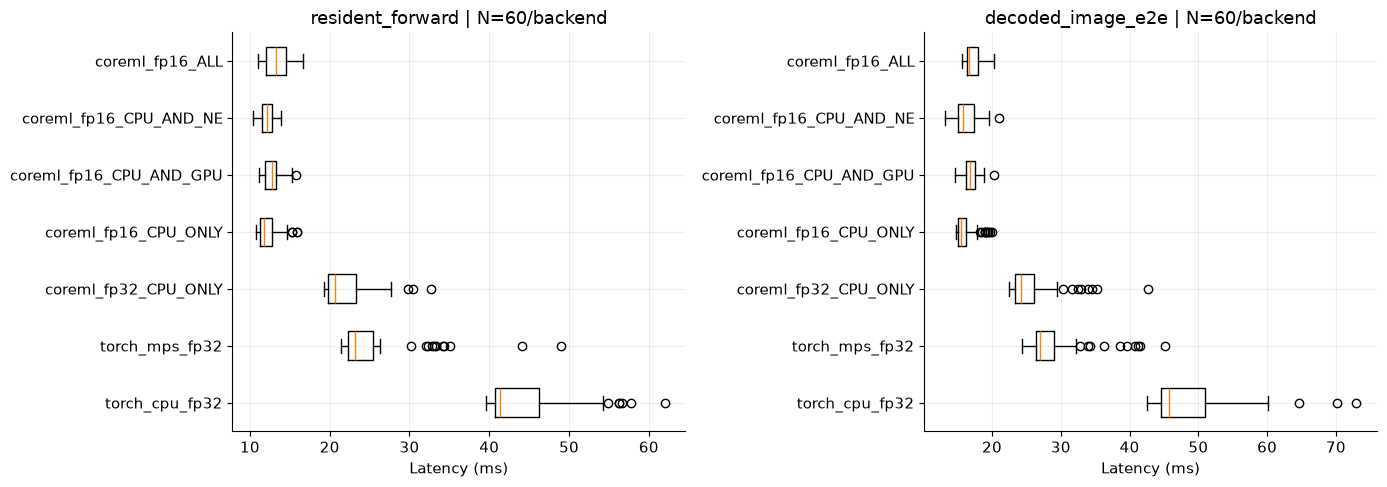

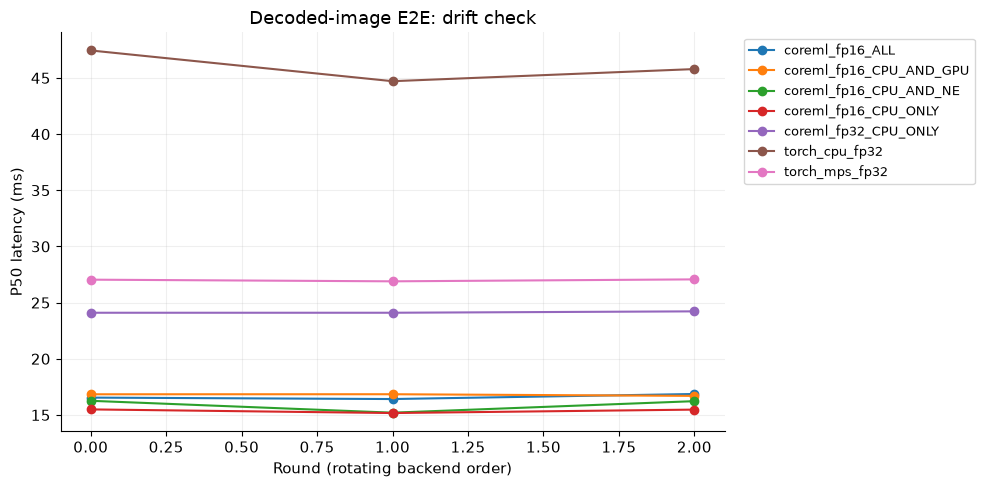

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, scope in zip(axes, ["resident_forward", "decoded_image_e2e"]):
    subset = latency[latency.scope == scope]
    names = list(runners)
    ax.boxplot([subset[subset.backend == name].ms for name in names], vert=False, tick_labels=names)
    ax.set(title=scope + f" | N={REPEATS*ROUNDS}/backend", xlabel="Latency (ms)")
fig.tight_layout()
fig.savefig(RUN / "latency_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

round_summary = latency[latency.scope == "decoded_image_e2e"].groupby(["round", "backend"]).ms.median().unstack()
ax = round_summary.plot(marker="o", figsize=(10, 5))
ax.set(xlabel="Round (rotating backend order)", ylabel="P50 latency (ms)", title="Decoded-image E2E: drift check")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.figure.tight_layout()
ax.figure.savefig(RUN / "latency_rounds.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. 汇总、证据归档和下一步判断

把误差最大的图先拿出来，检查 Top1 与 Top2 的 margin（分数间隔）。同样大小的误差，对大 margin 样本可能没影响，对小 margin 样本可能翻转类别。下表保存每图指标，避免平均值掩盖个别异常。

**cold latency 的边界：** 下载后第一次 CPU forward、CoreML load、load 后首次 predict 已分别记录，但进程和系统编译缓存可能是热的。本次不是“重启设备后的 true cold”。要测试 cold，另开独立进程并记录缓存状态；不要清理系统缓存来伪装可控变量。

In [16]:
per_image = []
for name, logits in all_logits.items():
    for i, sample_id in enumerate(sample_ids):
        sorted_ref = np.sort(reference[i])
        row = {"backend": name, "sample": sample_id, "reference_top1": int(reference[i].argmax()),
               "candidate_top1": int(logits[i].argmax()), "reference_top1_top2_margin": float(sorted_ref[-1]-sorted_ref[-2]),
               "max_abs": float(np.abs(reference[i]-logits[i]).max())}
        if labels is not None:
            row.update(label=int(labels[i]), correct=bool(logits[i].argmax()==labels[i]))
        per_image.append(row)
per_image = pd.DataFrame(per_image)
quality_table = pd.DataFrame(quality)
quality_table["top1_drop_pp"] = quality_table.iloc[0].top1_accuracy_pct - quality_table.top1_accuracy_pct
quality_table["status"] = np.where(quality_table.allclose_screen, "numerical screen passed; task gate pending", "investigate mismatch")
display(quality_table)
display(per_image.sort_values("max_abs", ascending=False).head(10))

# macOS ru_maxrss 单位 bytes；这是整个 notebook 进程的历史峰值，非每个后端峰值。
manifest["process_lifetime_peak_rss_MiB"] = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 2**20
manifest["mps_snapshot_allocated_MiB"] = torch.mps.current_allocated_memory() / 2**20
manifest["mps_snapshot_driver_MiB"] = torch.mps.driver_allocated_memory() / 2**20
manifest["memory_limitations"] = "process lifetime peak + MPS snapshots; not isolated per-backend or ANE peak"
manifest["trace_ms"] = trace_ms
manifest["artifacts"] = {str(p.relative_to(ART)): sha256(p) for p in ART.rglob("*") if p.is_file()}
for filename, table in [("quality.csv", quality_table), ("latency_raw.csv", latency),
                        ("latency_summary.csv", summary), ("per_image.csv", per_image),
                        ("build.csv", build_table), ("load_first_predict.csv", pd.DataFrame(load_rows))]:
    table.to_csv(RUN / filename, index=False)
np.savez(RUN / "all_logits.npz", **all_logits)
(RUN / "manifest.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2, default=str))
print("已保存证据:", RUN)
print("准确率状态:", "有标签子集评测；请核对代表性" if labels is not None else "无真实标签，Top-1/Top-5 未评测")

,backend,max_abs,mean_abs,mse,min_cosine,top1_agreement_pct,allclose_screen,top1_accuracy_pct,top5_accuracy_pct,top1_drop_pp,status
0,torch_cpu_fp32,0.000000,0.000000e+00,0.000000e+00,1.000000,100.0,True,NaN,NaN,NaN,numerical screen passed; task gate pending
1,torch_mps_fp32,0.000006,4.255435e-07,3.068768e-13,1.000000,100.0,True,NaN,NaN,NaN,numerical screen passed; task gate pending
2,coreml_fp32_CPU_ONLY,0.000004,3.470136e-07,2.259604e-13,1.000000,100.0,True,NaN,NaN,NaN,numerical screen passed; task gate pending
3,coreml_fp16_CPU_ONLY,0.038674,2.246766e-03,9.040602e-06,0.999972,100.0,True,NaN,NaN,NaN,numerical screen passed; task gate pending
4,coreml_fp16_CPU_AND_GPU,0.003495,4.266943e-04,3.050919e-07,0.999999,100.0,True,NaN,NaN,NaN,numerical screen passed; task gate pending
5,coreml_fp16_CPU_AND_NE,0.017781,1.171035e-03,2.615223e-06,0.999991,100.0,True,NaN,NaN,NaN,numerical screen passed; task gate pending
6,coreml_fp16_ALL,0.009464,7.369109e-04,9.612145e-07,0.999997,100.0,True,NaN,NaN,NaN,numerical screen passed; task gate pending


,backend,sample,reference_top1,candidate_top1,reference_top1_top2_margin,max_abs
11,coreml_fp16_CPU_ONLY,parrots/center-half,88,88,6.352178,0.038674
9,coreml_fp16_CPU_ONLY,parrots/original,88,88,6.160273,0.019180
17,coreml_fp16_CPU_AND_NE,parrots/center-half,88,88,6.352178,0.017781
10,coreml_fp16_CPU_ONLY,parrots/mirror,88,88,6.098317,0.016379
20,coreml_fp16_ALL,parrots/center-half,88,88,6.352178,0.009464
16,coreml_fp16_CPU_AND_NE,parrots/mirror,88,88,6.098317,0.009119
15,coreml_fp16_CPU_AND_NE,parrots/original,88,88,6.160273,0.008698
18,coreml_fp16_ALL,parrots/original,88,88,6.160273,0.004215
19,coreml_fp16_ALL,parrots/mirror,88,88,6.098317,0.003557
14,coreml_fp16_CPU_AND_GPU,parrots/center-half,88,88,6.352178,0.003495


已保存证据: /Users/yhwang/infer-proj/results/swin_stage1/20260919-182524-689195
准确率状态: 无真实标签，Top-1/Top-5 未评测


### 各路径要增加什么处理？

| 路径 | 前处理 | 额外处理 | 后处理与边界 |
|---|---|---|---|
|HF/PyTorch CPU|同一个 processor + RGB/EXIF|eval、inference_mode、固定线程|logits→argmax；softmax仅用于展示分数|
|PyTorch MPS|仍在 CPU 做同一 processor|参数/输入到mps，计时同步，禁用隐式fallback|输出回CPU；MPS只代表GPU|
|CoreML TensorType|仍由调用端完成相同前处理|FP32连续NumPy数组，匹配输入名/shape，编译并加载runtime|从字典取logits，匹配类别表|
|未来 CoreML ImageType|需逐项验证颜色、resize/crop、scale/bias|接口和 normalization 封装可能改变，必须重新做输入 parity|不能简单把PIL对象塞给本轮TensorType模型|
|未来 ONNX Runtime|同一 tensor 和语义契约|核对输入名、dtype、shape，选择provider|导出后单独保存ONNX输出并对齐，尚未执行|

ImageType 的单一 scale 不等于本模型每通道除不同 std；若迁移到图内 normalization，要显式实现并逐像素验证。TensorType 本轮避免重复归一化与隐藏图像前处理。**layout transform** 是改变 tensor 元素排列或访问表示的操作；后端的 private layout 是内部为硬件设计的存放格式，不能从输入 NCHW 推断内部始终 NCHW。

### 按结果做 engineering judgment

1. FP32 TorchScript 开始偏：先查 trace 的 shape/control-flow 与输出包装。
2. CoreML FP32 CPU 开始偏：优先查转换与算子语义，不归咎于 FP16。
3. FP32 正常但 FP16 开始偏：检查选定中间 tensor、极端输入和排名 margin；下一阶段暴露 CoreML 中间输出，对齐第一处分歧。尚不能排除后端实现问题。
4. 数值正常但有标签 accuracy 降：查看翻转样本/真实标签/预处理/数据分布，不能以 cosine 高结束调查。
5. E2E 慢而 forward 快：分别测 processor、数据适配和同步，判断 CPU 前处理/桥接是否值得优化。
6. CoreML CPU_AND_NE 慢：先拿计划/trace，再考虑 partition、layout、dispatch；本轮没有硬件计数器，不能单凭 latency 判定带宽或算力受限。

此阶段不做不明原因的手工 graph 改写。若要比较是否优化，固定一个受控变量，再重跑同输入、同产物记录、同测量口径。baseline 不达预期也有价值，解释未采用某条路径的成本与证据。

### 写下自己的第一个 case（不要把下面空白当成已经做过）

* Symptom（现象）：哪张图/哪个后端/哪项指标异常？
* Baseline（对照）：model/input hash、版本、配置是什么？
* Hypotheses（假设）：预处理、浮点误差、转换、调度分别怎么排除？
* Evidence（证据）：引用本次目录中的输入/逐层tensor/原始时延/trace。
* Root cause（根因）：证据能定位到哪一步？还有哪些只是推断？
* Fix / Before–After（修复及对照）：只改变了什么，指标怎么变？
* Side effect（副作用）：内存、冷启动、兼容性、维护成本？
* Regression test（回归检查）：保留哪张图/哪个tensor/哪个负控？
* Transferable lesson（可迁移经验）：下次同类问题先查什么？

## 9. 参考文档术语索引：先知道它在代码里干什么

覆盖 `swin-transformer-guideline.md` 各节的技术词、缩写与实验字段；本轮实际用到的概念见上文，其余是后续路线的阅读索引，不代表本轮已验证。下表不引入公司平台事实。

### 目标、评测与诊断（§一、二、六～十二、十七、二十三）

|词 / 英文原义|在项目里实际指什么|
|---|---|
|baseline / reference implementation（基线/参考实现）|后续修改都要比较的固定实现，这里是CPU FP32|
|SLO, Service Level Objective（服务目标）|例如延迟、精度必须达到的事先约定|
|hard constraint / optimization target|前者不满足就不能交付；后者满足约束后尽量改善|
|trade-off（取舍）|为更低时延付出精度、内存或维护成本|
|Pareto point（帕累托点）|不存在另一方案在所有目标上不差且至少一项更好的候选点|
|accuracy / accuracy drop / recovery|对真值答对比例 / 比基线少多少 / 修复后恢复多少|
|Top-1 / Top-5 / pp|第一名命中 / 前五名包含真值 / 百分点差|
|latency / P50 / P90 / mean|单次完成时间 / 中位数 / 90分位数 / 算术均值|
|cold / warm / warm-up|首次或冷缓存状态 / 稳态 / 正式计时前预热|
|E2E, end-to-end|从约定输入边界到最终输出的完整请求耗时，必须声明边界|
|model load / engine build|加载模型的运行时开销 / 构建执行产物的编译开销|
|model size / peak memory|磁盘产物字节数 / 某段执行期间内存峰值，二者不同|
|power / thermal / DVFS|功耗 / 温度相关行为 / Dynamic Voltage and Frequency Scaling，动态调压调频|
|device RAM / shared memory pressure|设备可用内存 / 多单元共用内存时的容量或带宽压力|
|power mode / long-running stability|电源策略 / 长时间运行是否出错或降速|
|correctness / parity / numerical mismatch|实现是否符合参考 / 对齐检查 / 数值对不上|
|validation dataset / dataset version|用于检查任务质量的数据集 / 其固定版本与样本清单|
|preprocessing / normalization / center crop|输入加工 / 按mean/std变换像素 / 从中央裁出区域|
|RGB / BGR / resize method / input layout|颜色顺序 / 相反顺序 / 缩放插值方式 / 各轴与元素排列|
|model commit / revision / hash / artifact|仓库提交 / 固定版本 / 内容指纹 / 输入、模型、日志等实验产物|
|intermediate output / selected tensors|网络中间结果 / 为定位问题挑出的观察点|
|max/mean abs error / cosine / MSE|最大/平均逐元素绝对差 / 向量方向相似度 / 均方差|
|activation distribution / min–max / percentile / histogram|激活值分布 / 范围 / 分位点 / 按区间计数图|
|outlier（离群值）|极少数幅值很大的元素，会影响量化范围|
|debugging / diagnosis / regression|定位错误的过程 / 系统诊断 / 新改动让旧能力退化|
|ablation（消融）/ control（对照）|一次拿掉或改变一个因素观察效果 / 不做该改动的对照|
|domain / random / class-balanced sampling|数据场景 / 随机抽样 / 各类别均衡抽样|
|easy/hard, day/night, indoor/outdoor|按难度或场景分桶，检查总平均数掩盖的问题|
|performance attribution / hotspot|把耗时归因到具体阶段或机制 / 最值得调查的高耗时区域|

### Swin 的运算与 tensor（§四、六、十六）

|词 / 英文原义|实际作用|
|---|---|
|Swin, Shifted Window Transformer|在局部窗口内做attention，并交替移动窗口来交换信息的分层视觉模型|
|Tiny / patch4 / window7 / 224|模型规模档位 / 初始4×4像素patch / 7×7 token窗口 / 本轮图像分辨率|
|tensor / shape / dtype|多维数值数组 / 每轴长度 / 每个元素的数值类型|
|Patch Embedding（小块嵌入）|把图像小块投影成特征向量，本实现可检视patch projection模块|
|token / hidden / channel|一个位置的特征向量 / 向量维度 / 特征通道；不是这里的文本词|
|block / stage|重复的计算单元 / 多个block组成的层级|
|LayerNorm（层归一化）|对一个token的特征轴求均值方差再标准化、缩放和平移|
|Linear / projection|对最后一个特征轴做矩阵乘权重再加bias|
|MatMul / GEMM|矩阵乘法 / General Matrix Multiply，通用矩阵乘接口|
|Q K V, Query Key Value|同一输入经不同投影得到的匹配向量与待聚合特征|
|Q @ K^T|Q与转置K做矩阵乘，得到token之间的匹配分数；T是转置|
|attention / Softmax|按匹配分数聚合V / 把一行分数变成和为1的权重|
|relative position bias|按窗口内相对位移查表，给attention分数加上位置偏置|
|window partition / window reverse|把空间token分成局部窗口 / 把窗口结果拼回原空间组织|
|shifted window / roll|移动窗口边界以交换邻域信息 / 对数组循环移位，配合mask处理边界|
|reshape / transpose / slice|重解释轴长度 / 交换轴顺序 / 取一个子区域，是否复制要看实现|
|GELU, Gaussian Error Linear Unit|按输入值平滑改变通过比例的逐元素激活函数|
|residual（残差连接）|分支输出加回输入，提供信息与梯度的直接路径|
|MLP, Multi-Layer Perceptron|这里通常是Linear→GELU→Linear的特征变换分支|
|matrix-heavy / vector / reduction|主要矩阵计算 / 逐元素向量计算 / 把一个轴上的多个值聚合成更少值|
|CNN, Convolutional Neural Network / ResNet|以卷积为主的网络 / 使用残差连接的经典模型族|

### 量化术语：后续阶段再执行（§五～十、二十三）

|词 / 英文原义|实际作用|
|---|---|
|quantization / linear quantization|把数值映射到有限表示 / 用scale与zero-point在整数和实数间换算|
|FP32 / FP16 / INT8 / INT4|32/16位浮点 / 8/4位整数；存储宽度不保证对应硬件计算路径|
|Weight / Activation|模型学习好的参数 / 一次forward产生的中间tensor|
|W8A16 / W8A8 / W16A16|权重8位激活16位 / 两者8位 / 两者16位；还需说明浮点或整数等具体格式|
|quantization matrix / Q0～Q5|实验配置表 / 文档给各行取的编号，不是硬件格式名称|
|per-tensor / per-channel / per-block granularity|整个tensor一组量化参数 / 每通道一组 / 每块一组|
|scale / zero-point|整数一步对应多少实数 / 实数0对应哪个整数|
|calibration / calibration set|用代表性输入统计激活范围 / 为此准备的样本集，不用于最终验收|
|calibration size / distribution|校准样本数量 / 校准数据覆盖的场景与数值范围|
|clipping / weight clipping|把范围外数值截到阈值 / 对权重做这个操作以换取量化分辨率|
|weight climb|参考文档明确没有确认它是常用术语，可能想表达weight clipping，不能当成正式方法|
|mixed precision configuration|不同层或不同tensor采用不同精度的完整配置|
|layer sensitivity analysis|受控改变某层精度，测任务指标变化，定位敏感区域|
|layer/block restore / FP16 fallback|把选定层/块恢复高精度 / 这里指精度回退，不能与CPU设备fallback混为一谈|
|accuracy recovery / arithmetic|恢复高精度后挽回的正确率 / 实际数值运算|
|PTQ, Post-Training Quantization|训练完成后做量化，通常配合校准，无需完整重训|
|W4 / weight-only|4位权重 / 只压权重，激活与实际算术格式需要另查|

### 编译、runtime 与 profiling（§三、十一～十六、十九～二十三）

|词 / 英文原义|实际作用|
|---|---|
|framework / backend / runtime|构造并执行模型的上层库 / 承接运算的后端 / 加载产物、分配资源、派发执行的软件|
|PyTorch / Hugging Face Transformers|张量与自动求导框架 / 提供模型结构、checkpoint加载和processor的库|
|ONNX, Open Neural Network Exchange|跨框架计算图格式，用Protobuf存节点、边和tensor信息|
|Core ML / Core ML Tools / MIL|Apple推理框架 / 转换与优化工具 / 其模型中间表示|
|graph / IR, Intermediate Representation|运算节点及依赖关系 / 编译器在转换阶段维护的程序表示|
|graph fusion / layer fusion / fused function|把多个运算组织成一个更大区域 / 层融合 / 融合后函数；不自动等于一个kernel|
|kernel / kernel selection / kernel instruction|设备执行的计算程序 / 从实现中选用一个 / kernel最终执行的机器指令|
|kernel scheduling|决定kernel内循环怎样分块、并行和映射线程；不要与runtime队列调度混淆|
|graph partition / backend partition|把计算图分成由不同后端处理的区域|
|pattern / pattern matching|待识别的算子连接结构 / 扫描IR找出符合该结构的子图|
|TVM Relax / TIR|Relax表示张量级图与程序；TIR显式表示循环、索引和buffer读写|
|schedule / codegen / lowering|组织循环与执行映射 / 生成目标表示或代码 / 把高层算子逐步改成更低层实现|
|layout / reformat / format conversion|元素排列或访问约定 / 换排列的操作 / 在后端要求的格式间适配|
|heterogeneous execution / device mapping|多个不同计算单元协作执行 / 每个区域分配给哪个设备|
|operator support / backend compatibility / target legality|支持哪些算子 / 整体接口能否适配 / 某操作在目标硬件上是否满足限制|
|execution-unit experiment / CPU_ONLY等|限制允许设备集合做对照实验；四种CoreML配置见上文|
|engine / custom backend / plugin|构建好的执行实例 / 自己接入的运算后端 / 扩展不直接支持的算子等功能|
|profiling / profiler / trace / timeline|采集性能证据 / 采样工具 / 原始事件记录 / 事件随时间的排列|
|Instruments / Core ML trace|Apple性能工具 / CoreML执行相关事件证据|
|memory bandwidth / utilization|每秒实际搬运字节数 / 使用能力占可用能力的比例，需说明分母|
|roofline|用运算量/搬运字节的比值，结合算力和带宽上限估计性能受限方向|
|H2D / D2H|Host to Device / Device to Host，主机与设备的数据转移或接口适配|
|camera/application pipeline|摄像头采集到业务结果的完整处理链，远大于一次模型forward|

### 后续硬件与 kernel 路线（§十三～二十二）

|词 / 英文原义|实际作用|
|---|---|
|ANE, Apple Neural Engine / M1|Apple神经网络加速单元 / 本轮主机SoC；不可直接由PyTorch MPS调用|
|CPU / GPU / NPU / SoC|通用处理器 / 图形与并行计算处理器 / 神经网络加速器 / 集成多类单元的芯片|
|Metal / CUDA / HIP / Triton|Apple GPU接口 / NVIDIA GPU平台与编程模型 / AMD的CUDA风格可移植接口 / 编写计算kernel的语言与编译工具|
|TensorRT / engine build|NVIDIA推理优化与runtime栈 / 把模型构成可执行engine的过程|
|Nsight Systems / Nsight Compute|观察应用与设备时间线 / 深入分析GPU kernel的工具|
|Tensor Core utilization|矩阵专用单元利用率；不是所有GPU运算都使用它|
|GPU Grid / Block / Warp|一次launch的线程块集合 / 共享协作资源的线程组 / 硬件成组调度的线程单位；不是tensor轴|
|thread / warp reduction / block reduction|一个执行线程 / warp内聚合 / block内聚合|
|SIMD, Single Instruction Multiple Data|一条指令处理多份数据，与线程数量不是同一概念|
|tile / slice|为局部计算划分的小块 / 选出的子区域，常用于减少重复搬运|
|local SRAM / shared memory / register|片上存储 / 协作线程可共享的片上区域 / 线程计算时的高速操作数存储|
|DMA, Direct Memory Access / barrier / sync|由搬运引擎传输数据 / 多执行者等待到同一点 / 等待依赖完成|
|naive kernel / vectorized load-store|直接实现的基线 / 每条访存指令处理多个相邻元素|
|alignment / tail|起始地址满足访存粒度 / 分块后剩下不足一整块的元素，如hidden=1000|
|occupancy|驻留活跃warp等资源的占用程度，定义依架构；高不必然快|
|NVIDIA L4/A10/A10G/T4/A100/H100|不同代际/定位的GPU型号，参考文档用于选择验证环境，本轮不采购或测评|
|Jetson / Orin Nano / JetPack|NVIDIA端侧平台 / 其中的设备系列 / 配套系统与CUDA推理开发工具集|
|TOPS / TFLOPS|每秒万亿次整数操作 / 浮点运算；需声明精度与计数口径，不能直接换算模型FPS|
|Google Cloud G2 / AWS G5/G6|云实例系列；机型、价格和可用性须使用前重新核验|
|Qualcomm AI Hub / Workbench|提交编译、profile、推理等远端任务的服务；实际任务能力以当前文档为准|
|QNN / QAIRT / Hexagon|Qualcomm神经网络SDK / AI runtime工具栈 / 其加速器架构品牌；不能与Apple内部机制等同|
|hosted device / simulator|服务托管的实体设备 / 软件模拟环境，实验结果要标明来自哪种|
|ROCm / ROCr / queue|AMD GPU软件栈 / 其中的底层runtime / 提交待执行任务的队列|
|AMD Instinct MI300 / MI300X / Developer Cloud / credit|数据中心加速器系列 / 型号 / 云开发服务 / 使用额度；非本轮必需|
|AI compiler / edge deployment|研究图与kernel怎样变成后端执行 / 把模型在设备约束下交付并持续验证|
|white-box kernel / portability|实现可见且可修改的kernel / 将同一算法适配另一套接口与架构|

⚠️ 云实例型号、开发者额度及其他厂商细节本轮用不到，可先跳过；本表只解释角色，不复述原文可能过时的价格、资源数量或峰值性能。

## 10. 可核验来源与完成标准

本仓库路线依据：[Swin 指导文档 §二、三、十一、十二](../../docs/swin-transformer-guideline.md)；方法口径：[端侧部署详答 §22～24](../../docs/Detailed‑Answers‑for‑Edge‑AI‑Deployment.md)；[Learning-Guide](../../Learning-Guide.md) 的固定模型/输入/版本原则。参考文档的聊天引用占位符不作为可点击证据。

外部 API 与术语核验（创建时核验 2026-09-19，实际版本见manifest）：

* [Hugging Face Swin 模型与结构文档](https://huggingface.co/docs/transformers/v4.51.3/en/model_doc/swin)；[固定版本 checkpoint](https://huggingface.co/microsoft/swin-tiny-patch4-window7-224/tree/d00d478bfaf1f417d34a1186673ad4b4be264c51)。
* [固定版本前处理配置](https://huggingface.co/microsoft/swin-tiny-patch4-window7-224/blob/d00d478bfaf1f417d34a1186673ad4b4be264c51/preprocessor_config.json)：本轮前处理配置的事实来源。
* [PyTorch MPS 后端](https://docs.pytorch.org/docs/stable/notes/mps.html)；[MPS synchronize](https://docs.pytorch.org/docs/stable/generated/torch.mps.synchronize.html)。
* [Apple PyTorch→CoreML 工作流](https://apple.github.io/coremltools/docs-guides/source/convert-pytorch-workflow.html)：转换路线与模型捕获边界。
* [CoreML Model APIs](https://apple.github.io/coremltools/source/coremltools.models.html)：CompiledMLModel、ComputePlan 与配置语义；本机 `help(ct.models.CompiledMLModel)` 可核对已安装接口。
* [ImageNet-1k 数据集说明](https://huggingface.co/datasets/ILSVRC/imagenet-1k)：正式任务评测应使用合法取得且标签映射经过验证的 validation split。

**阶段一完成检查：** 能重跑固定输入；负控确实被拦截；CPU/MPS/TorchScript/CoreML 输出都有证据；有标签时报告Top-1/Top-5及样本数量；测量区分编译/加载/首次/稳态/E2E；ANE实测证据不足就明确留空；有一份自己调查过的case。没有标签与runtime trace时，这份Notebook完成的是“可运行的数值与性能baseline”，还不是完整的部署验收。

无界面顺序执行并保存输出：

```bash
uv run jupyter nbconvert --execute --to notebook --inplace --ExecutePreprocessor.timeout=1800 notebooks/swin_transformer/01_stage1_trustworthy_baseline.ipynb
```

`--execute` 顺序执行，`--inplace` 保存输出到原文件，`timeout=1800` 允许单格最长30分钟；失败会保留错误供定位，不能跳过后声称全部通过。